In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63079446 entries, 0 to 63079445
Data columns (total 18 columns):
 #   Column             Dtype  
---  ------             -----  
 0   YEAR               int16  
 1   MONTH              int8   
 2   DAY_OF_WEEK        int8   
 3   OP_UNIQUE_CARRIER  object 
 4   ORIGIN             object 
 5   DEST               object 
 6   CRS_DEP_TIME       int16  
 7   CRS_ARR_TIME       int16  
 8   CANCELLED          bool   
 9   CRS_ELAPSED_TIME   float32
 10  DISTANCE           float32
 11  DeparturePeriod    object 
 12  ArrivalPeriod      object 
 13  FlightLength       object 
 14  DistanceCategory   object 
 15  Season             object 
 16  CancelledLabel     object 
 17  DayName            object 
dtypes: bool(1), float32(2), int16(3), int8(2), object(10)
memory usage: 5.7+ GB


In [53]:
# Count unique entries
unique_count = df['OP_UNIQUE_CARRIER'].nunique()
print("Number of unique entries:", unique_count)

Number of unique entries: 20


In [54]:
# Count unique entries
unique_count = df['ORIGIN'].nunique()
print("Number of unique entries:", unique_count)

Number of unique entries: 390


In [55]:
# Count unique entries
unique_count = df['DEST'].nunique()
print("Number of unique entries:", unique_count)

Number of unique entries: 388


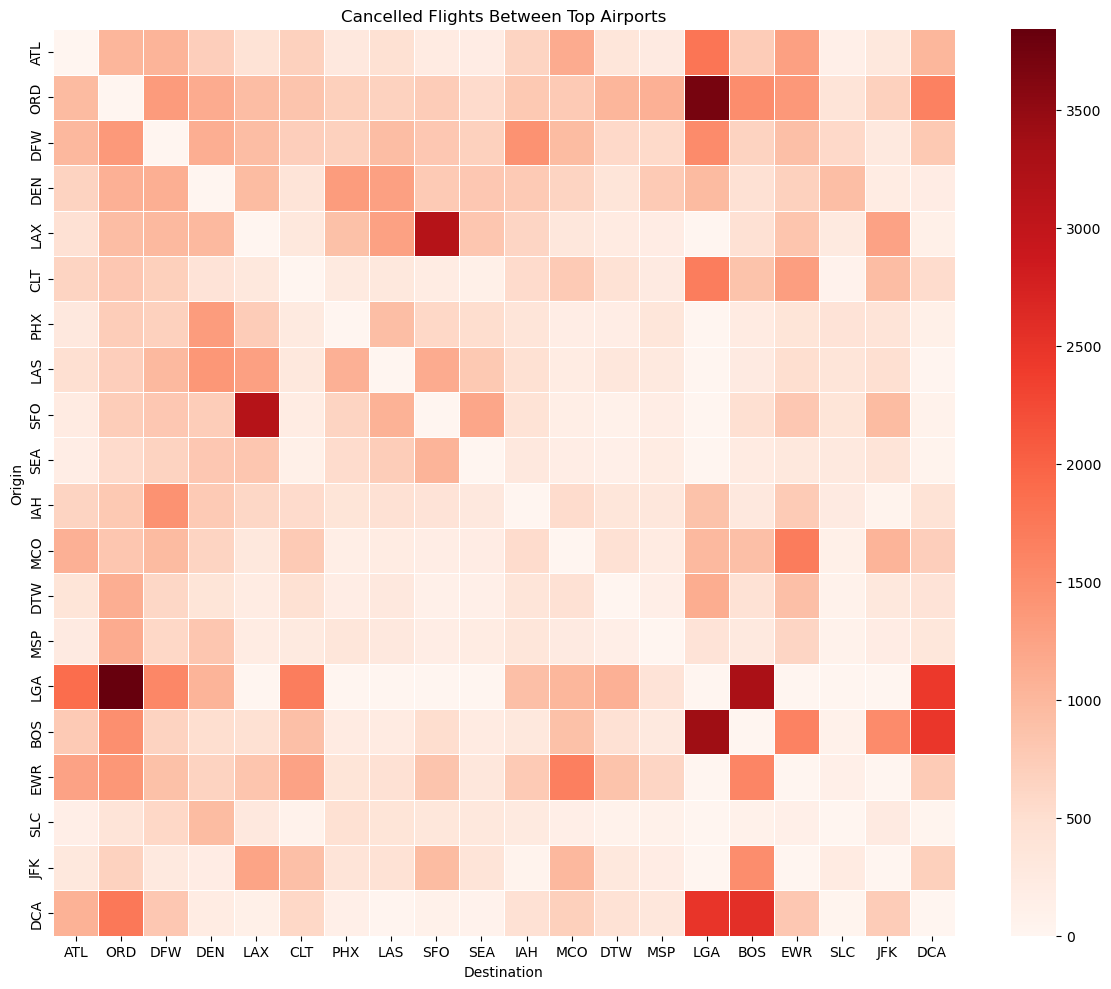

In [56]:
import seaborn as sns

# Create pivot table
pivot = cancelled_df.pivot_table(index='ORIGIN', columns='DEST', aggfunc='size', fill_value=0)

# Optional: filter top airports
top_airports = df['ORIGIN'].value_counts().head(20).index
pivot = pivot.loc[top_airports, top_airports]

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(pivot, cmap='Reds', linewidths=0.5)
plt.title('Cancelled Flights Between Top Airports')
plt.xlabel('Destination')
plt.ylabel('Origin')
plt.tight_layout()
plt.show()

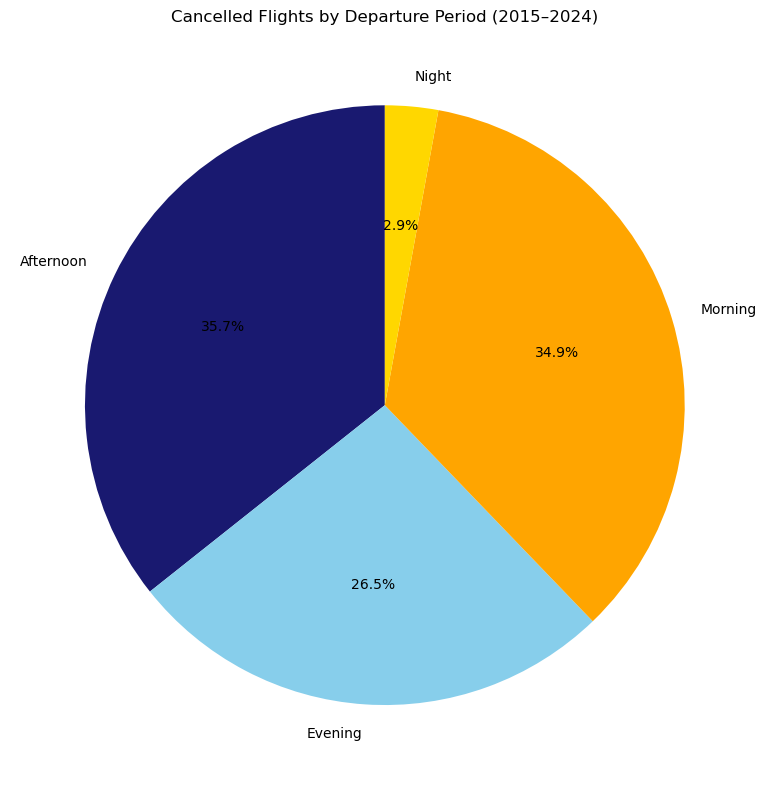

In [58]:
# Filter only cancelled flights
cancelled_df = df[df['CANCELLED'] == True]

# Count cancellations by DeparturePeriod
period_counts = cancelled_df['DeparturePeriod'].value_counts().sort_index()

# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(period_counts,
        labels=period_counts.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=['midnightblue', 'skyblue', 'orange', 'gold'])

plt.title('Cancelled Flights by Departure Period (2015–2024)')
plt.tight_layout()
plt.show()

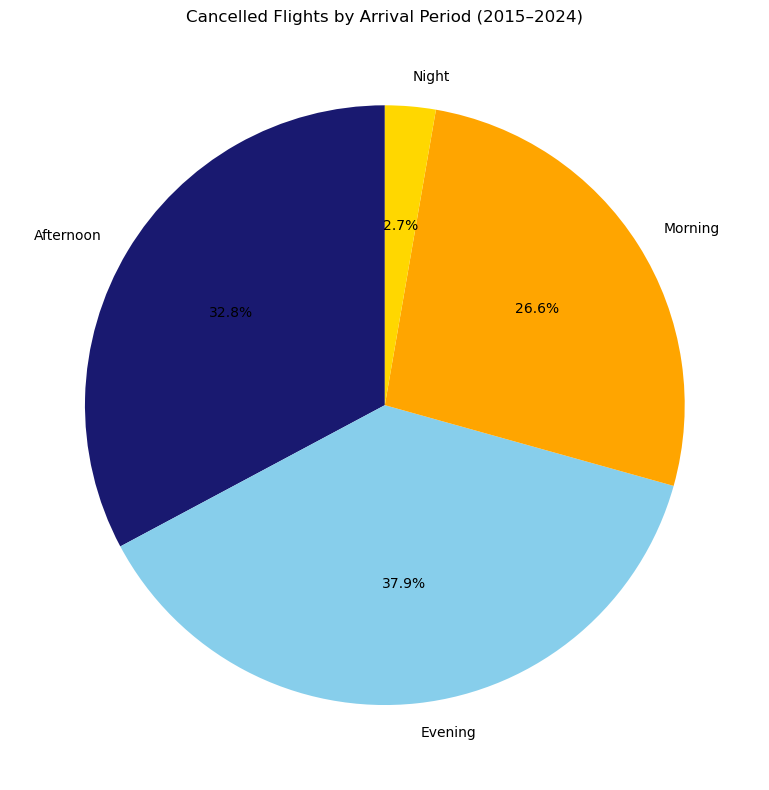

In [59]:
# Filter only cancelled flights
cancelled_df = df[df['CANCELLED'] == True]

# Count cancellations by ArrivalPeriod
arrival_counts = cancelled_df['ArrivalPeriod'].value_counts().sort_index()

# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(arrival_counts,
        labels=arrival_counts.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=['midnightblue', 'skyblue', 'orange', 'gold'])

plt.title('Cancelled Flights by Arrival Period (2015–2024)')
plt.tight_layout()
plt.show()

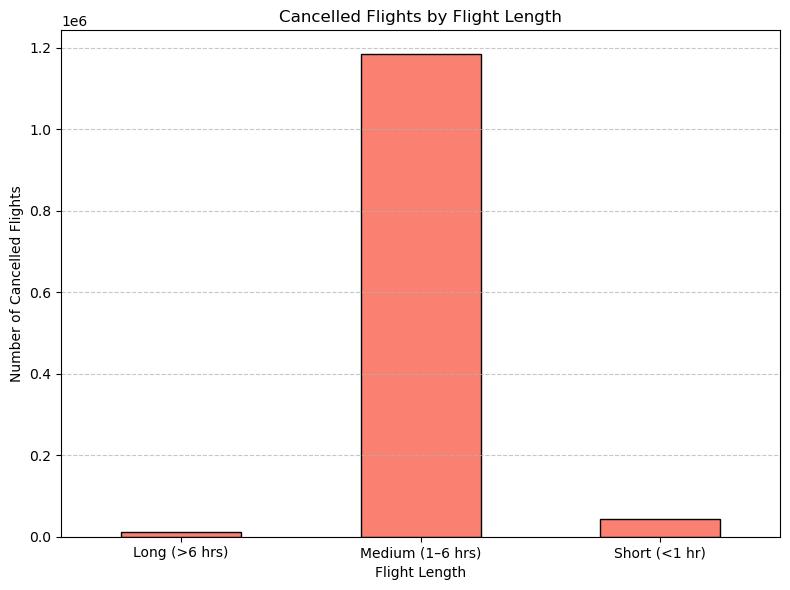

In [60]:
# Filter cancelled flights
cancelled_df = df[df['CANCELLED'] == True]

# Count cancellations by FlightLength
length_counts = cancelled_df['FlightLength'].value_counts().sort_index()

# Plot bar chart
plt.figure(figsize=(8, 6))
length_counts.plot(kind='bar', color='salmon', edgecolor='black')

plt.title('Cancelled Flights by Flight Length')
plt.xlabel('Flight Length')
plt.ylabel('Number of Cancelled Flights')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

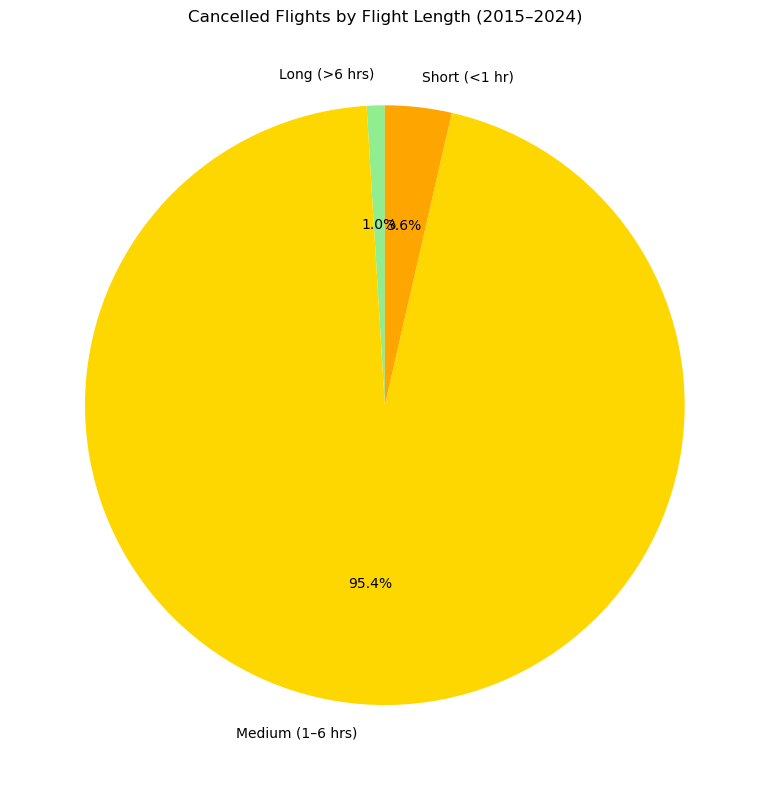

In [61]:
# Filter only cancelled flights
cancelled_df = df[df['CANCELLED'] == True]

# Count cancellations by FlightLength
length_counts = cancelled_df['FlightLength'].value_counts().sort_index()

# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(length_counts,
        labels=length_counts.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=['lightgreen', 'gold', 'orange', 'red'])

plt.title('Cancelled Flights by Flight Length (2015–2024)')
plt.tight_layout()
plt.show()

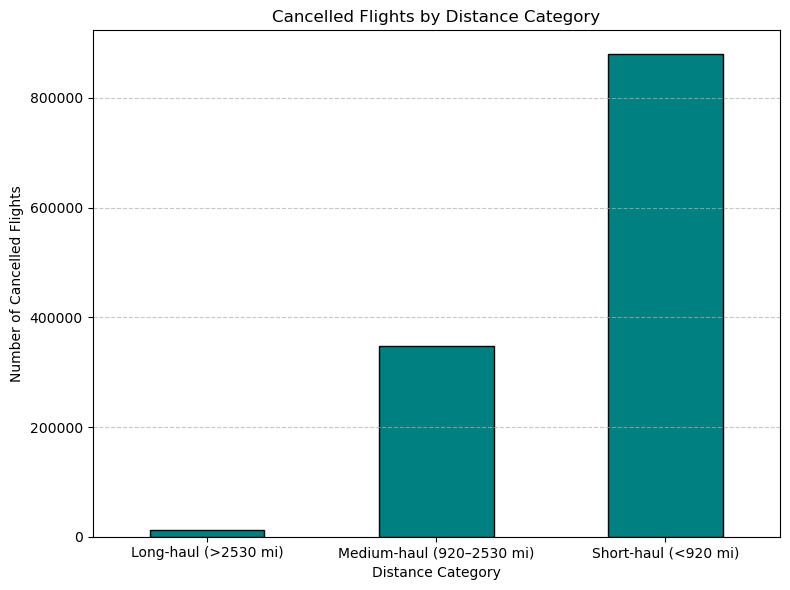

In [62]:
# Filter cancelled flights
cancelled_df = df[df['CANCELLED'] == True]

# Count cancellations by DistanceCategory
distance_counts = cancelled_df['DistanceCategory'].value_counts().sort_index()

# Plot bar chart
plt.figure(figsize=(8, 6))
distance_counts.plot(kind='bar', color='teal', edgecolor='black')

plt.title('Cancelled Flights by Distance Category')
plt.xlabel('Distance Category')
plt.ylabel('Number of Cancelled Flights')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

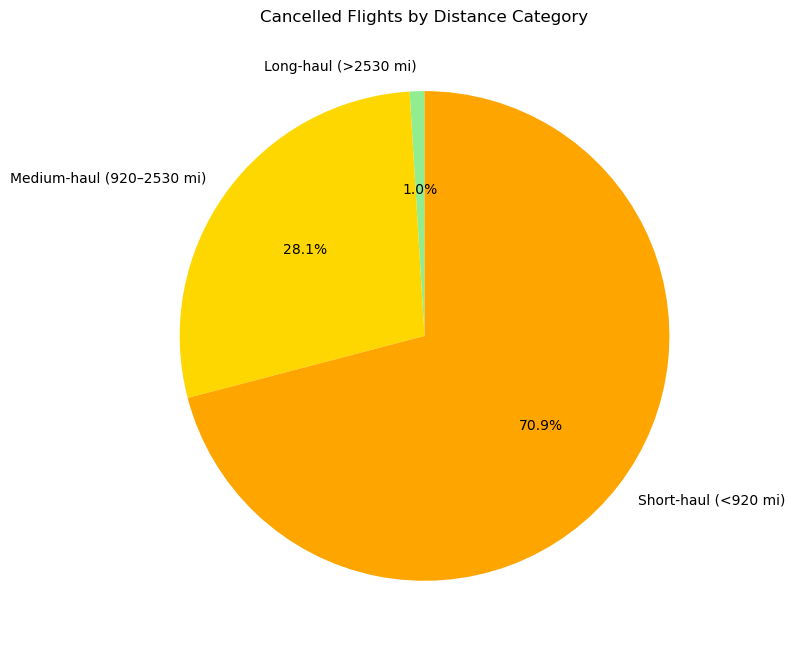

In [63]:
# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(distance_counts,
        labels=distance_counts.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=['lightgreen', 'gold', 'orange', 'red'])

plt.title('Cancelled Flights by Distance Category')
plt.tight_layout()
plt.show()

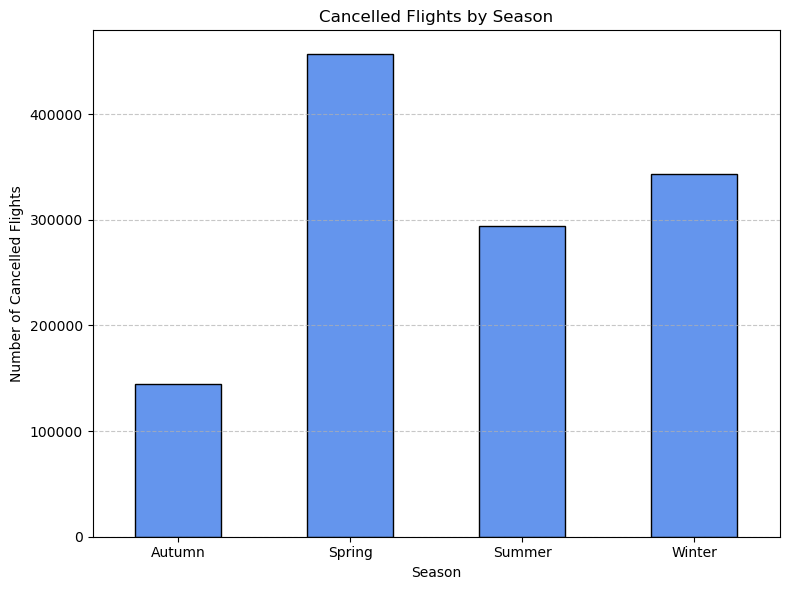

In [64]:
# Filter cancelled flights
cancelled_df = df[df['CANCELLED'] == True]

# Count cancellations by Season
season_counts = cancelled_df['Season'].value_counts().sort_index()

# Plot bar chart
plt.figure(figsize=(8, 6))
season_counts.plot(kind='bar', color='cornflowerblue', edgecolor='black')

plt.title('Cancelled Flights by Season')
plt.xlabel('Season')
plt.ylabel('Number of Cancelled Flights')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

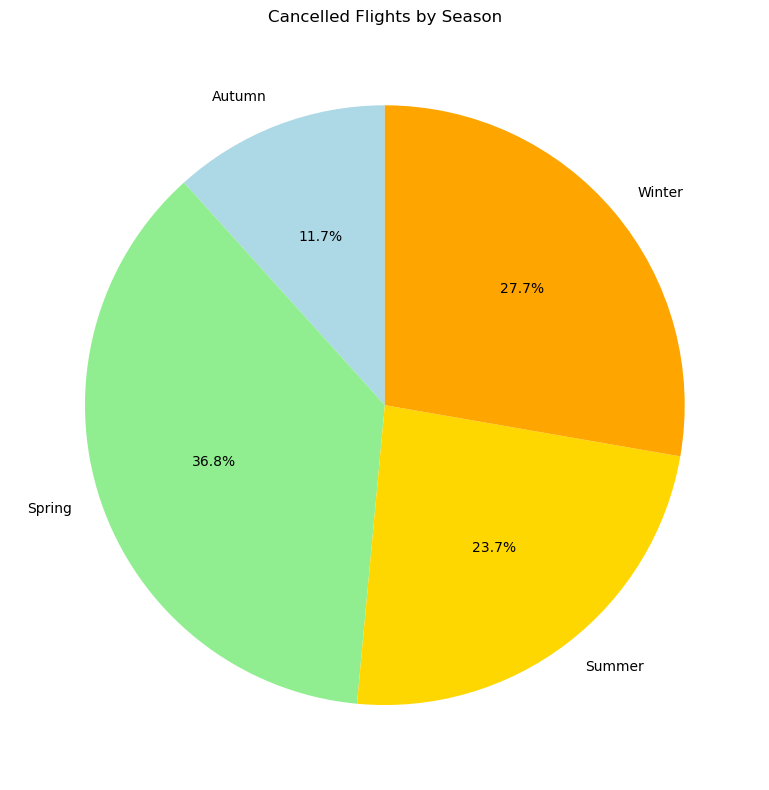

In [65]:
# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(season_counts,
        labels=season_counts.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=['lightblue', 'lightgreen', 'gold', 'orange'])

plt.title('Cancelled Flights by Season')
plt.tight_layout()
plt.show()

<Axes: title={'center': 'Cancellation Rate by Year'}, xlabel='YEAR', ylabel='Rate (%)'>

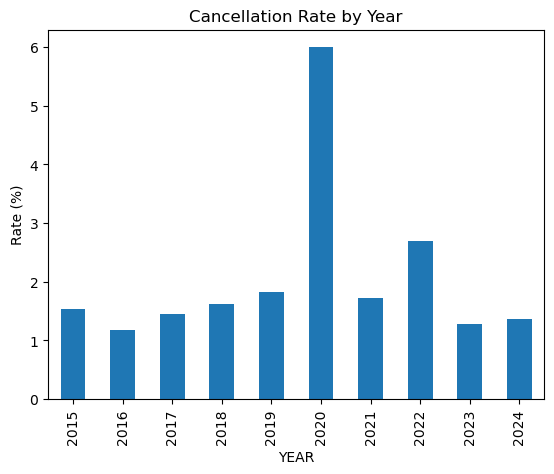

In [67]:
year_total = df['YEAR'].value_counts()
year_cancelled = df[df['CANCELLED'] == True]['YEAR'].value_counts()
year_rate = (year_cancelled / year_total * 100).sort_index()

year_rate.plot(kind='bar', title='Cancellation Rate by Year', ylabel='Rate (%)')

<Axes: title={'center': 'Cancellation Rate by Season'}, xlabel='Season', ylabel='Rate (%)'>

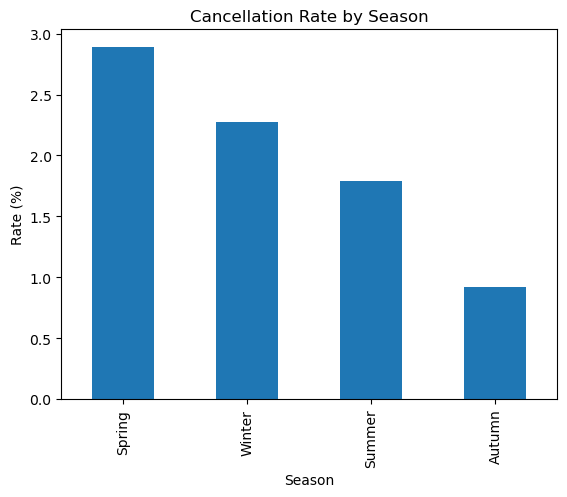

In [68]:
season_total = df['Season'].value_counts()
season_cancelled = df[df['CANCELLED'] == True]['Season'].value_counts()
season_rate = (season_cancelled / season_total * 100).sort_values(ascending=False)

season_rate.plot(kind='bar', title='Cancellation Rate by Season', ylabel='Rate (%)')

<Axes: title={'center': 'Cancellation Rate by Month'}, xlabel='MONTH', ylabel='Rate (%)'>

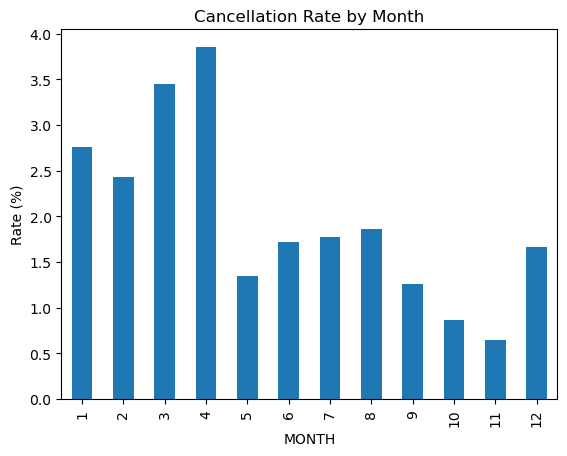

In [69]:
month_total = df['MONTH'].value_counts()
month_cancelled = df[df['CANCELLED'] == True]['MONTH'].value_counts()
month_rate = (month_cancelled / month_total * 100).sort_index()

month_rate.plot(kind='bar', title='Cancellation Rate by Month', ylabel='Rate (%)')


<Axes: title={'center': 'Cancellation Rate by Weekday'}, xlabel='DAY_OF_WEEK', ylabel='Rate (%)'>

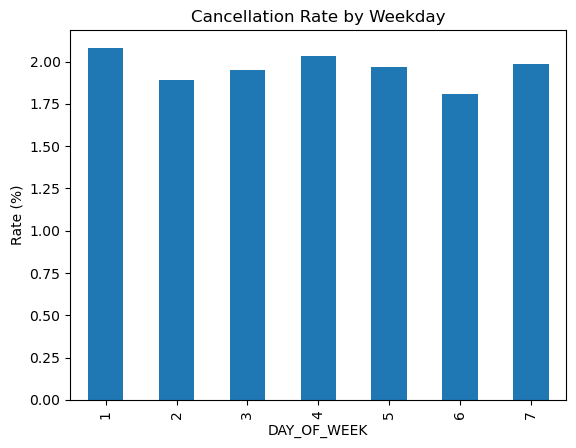

In [70]:
weekday_total = df['DAY_OF_WEEK'].value_counts()
weekday_cancelled = df[df['CANCELLED'] == True]['DAY_OF_WEEK'].value_counts()
weekday_rate = (weekday_cancelled / weekday_total * 100).sort_index()

weekday_rate.plot(kind='bar', title='Cancellation Rate by Weekday', ylabel='Rate (%)')

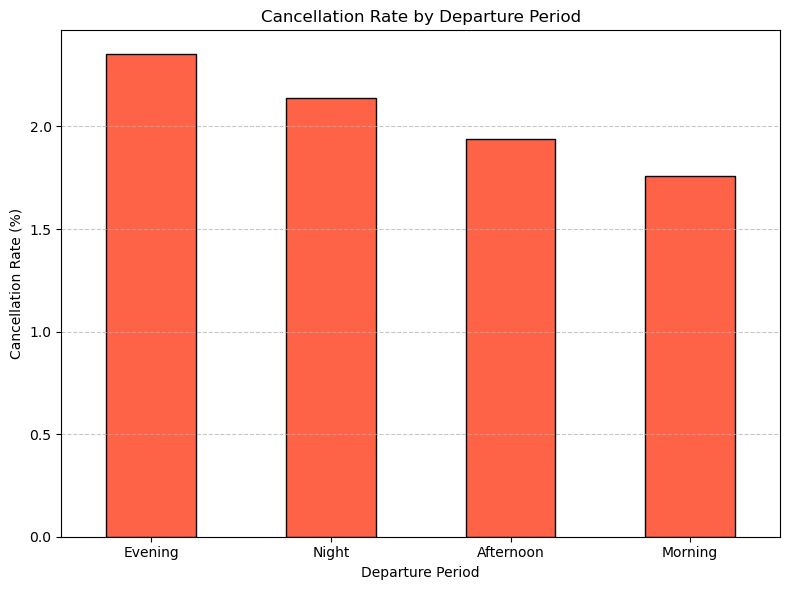

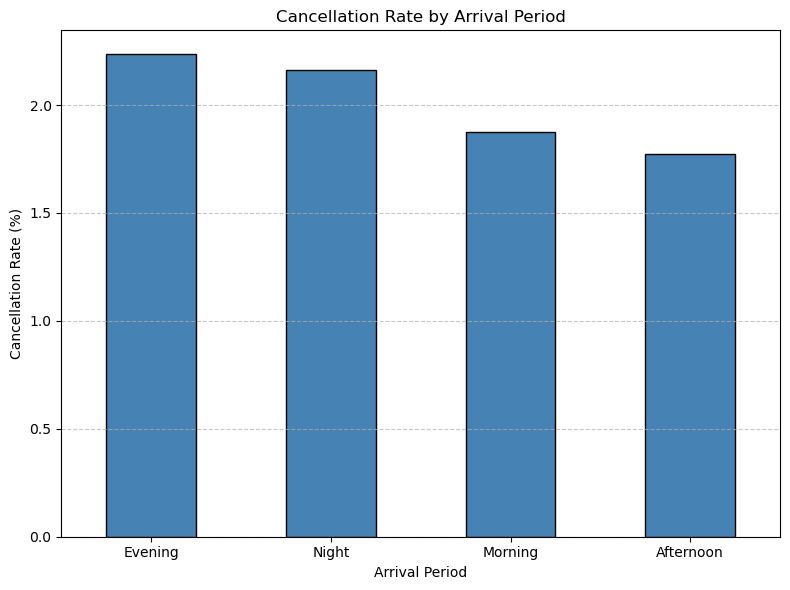

In [90]:
# Function to compute cancellation rate
def compute_cancellation_rate(df, column):
    total = df[column].value_counts()
    cancelled = df[df['CANCELLED'] == True][column].value_counts()
    cancelled = cancelled.reindex(total.index, fill_value=0)
    return (cancelled / total * 100).sort_values(ascending=False)

# Compute rates
departure_rate = compute_cancellation_rate(df, 'DeparturePeriod')
arrival_rate = compute_cancellation_rate(df, 'ArrivalPeriod')

# Plot: DeparturePeriod
plt.figure(figsize=(8, 6))
departure_rate.plot(kind='bar', color='tomato', edgecolor='black')
plt.title('Cancellation Rate by Departure Period')
plt.xlabel('Departure Period')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Plot: ArrivalPeriod
plt.figure(figsize=(8, 6))
arrival_rate.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Cancellation Rate by Arrival Period')
plt.xlabel('Arrival Period')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

<Axes: title={'center': 'Cancellation Rate by Carrier'}, xlabel='OP_UNIQUE_CARRIER', ylabel='Rate (%)'>

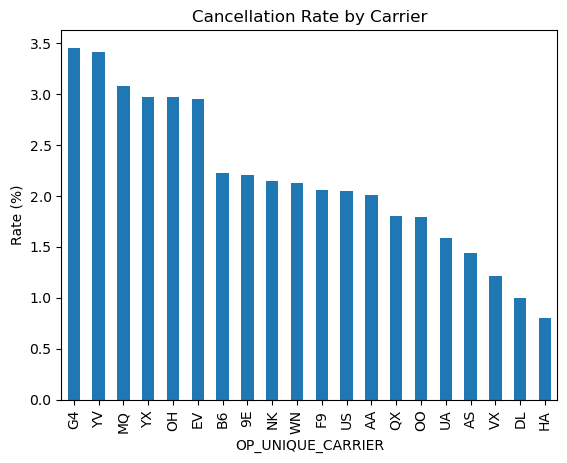

In [72]:
carrier_total = df['OP_UNIQUE_CARRIER'].value_counts()
carrier_cancelled = df[df['CANCELLED'] == True]['OP_UNIQUE_CARRIER'].value_counts()
carrier_rate = (carrier_cancelled / carrier_total * 100).sort_values(ascending=False)

carrier_rate.plot(kind='bar', title='Cancellation Rate by Carrier', ylabel='Rate (%)')

Text(0.5, 1.0, 'Cancellation Rate Heatmap: Origin vs Destination')

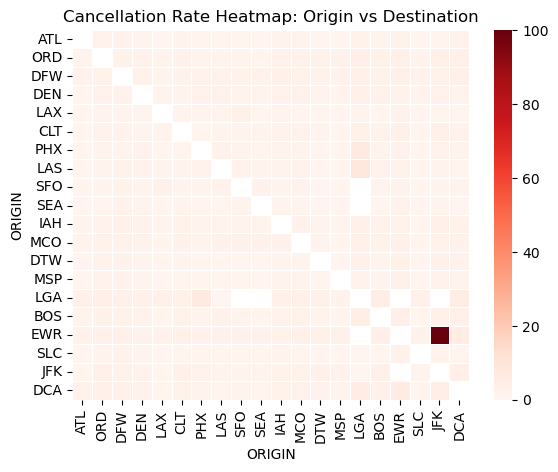

In [73]:
# Pivot table of cancellation rate
pivot = df.pivot_table(index='ORIGIN', columns='DEST',
                       values='CANCELLED', aggfunc='mean') * 100

# Optional: filter top airports
top_airports = df['ORIGIN'].value_counts().head(20).index
pivot = pivot.loc[top_airports, top_airports]

sns.heatmap(pivot, cmap='Reds', linewidths=0.5)
plt.title('Cancellation Rate Heatmap: Origin vs Destination')

<Axes: title={'center': 'Cancellation Rate by Flight Length'}, xlabel='FlightLength', ylabel='Rate (%)'>

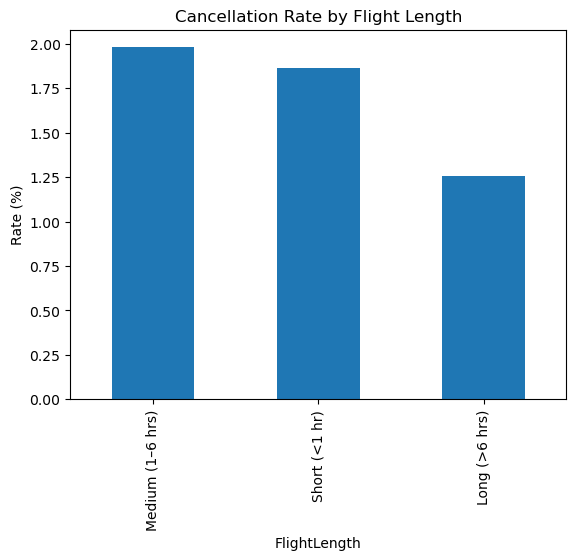

In [74]:
length_total = df['FlightLength'].value_counts()
length_cancelled = df[df['CANCELLED'] == True]['FlightLength'].value_counts()
length_rate = (length_cancelled / length_total * 100).sort_values(ascending=False)

length_rate.plot(kind='bar', title='Cancellation Rate by Flight Length', ylabel='Rate (%)')

<Axes: title={'center': 'Cancellation Rate by Distance Category'}, xlabel='DistanceCategory', ylabel='Rate (%)'>

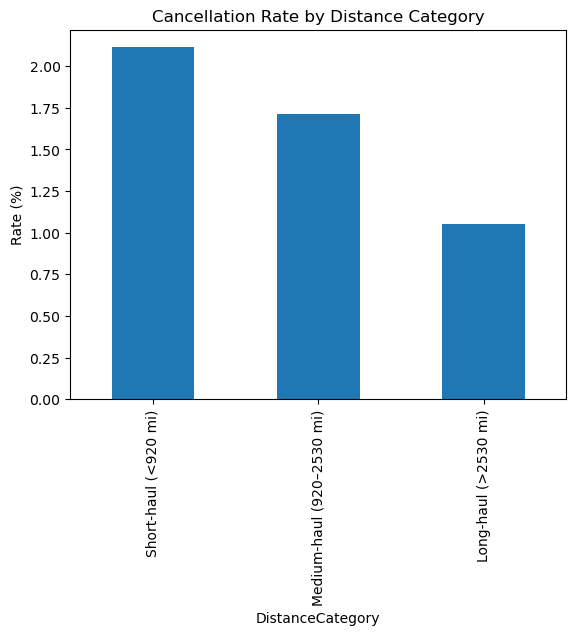

In [75]:
distance_total = df['DistanceCategory'].value_counts()
distance_cancelled = df[df['CANCELLED'] == True]['DistanceCategory'].value_counts()
distance_rate = (distance_cancelled / distance_total * 100).sort_values(ascending=False)

distance_rate.plot(kind='bar', title='Cancellation Rate by Distance Category', ylabel='Rate (%)')

In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 63079445 entries, 0 to 63079445
Data columns (total 18 columns):
 #   Column             Dtype  
---  ------             -----  
 0   YEAR               int16  
 1   MONTH              int8   
 2   DAY_OF_WEEK        int8   
 3   OP_UNIQUE_CARRIER  object 
 4   ORIGIN             object 
 5   DEST               object 
 6   CRS_DEP_TIME       int16  
 7   CRS_ARR_TIME       int16  
 8   CANCELLED          bool   
 9   CRS_ELAPSED_TIME   float32
 10  DISTANCE           float32
 11  DeparturePeriod    object 
 12  ArrivalPeriod      object 
 13  FlightLength       object 
 14  DistanceCategory   object 
 15  Season             object 
 16  CancelledLabel     object 
 17  DayName            object 
dtypes: bool(1), float32(2), int16(3), int8(2), object(10)
memory usage: 6.2+ GB
